## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?

Regression predicts a numeric or continous outcome and classification predicts a categorical variable. Typically the outputs of a classification will be categorical which will result in a type of label.

2. What is a confusion table/matrix? What does it help us understand about a model's performance?

A confusion matrix compares actual and predicted values. It helps us understand which variables were predicted well and which aren't.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?

Accuracy would be defined by the number of correct predictions out of total predictions. This might not be entirely sufficient because of potentially imbalanced datasets. In other words, it does not differntiate between the numbers of correctly classified examples suggesting the entire dataset might not be entirely represented.

4. What does the root mean squared error quantify about a particular model?

RSME quantifies the average magnitude of prediction error.

5. What are overfitting and underfitting?

Overfitting typically occurs when K is too small. Overfitting would be a model being too complex as it memorizes the training data and has very high training accuracy but low test accuracy. The underfitting would suggest a weak model and a too large of a K. Furthermore, underfitting would would be too simple to truly understand deeper patterns.

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?

We split the training data between training data and testing data. The training set will help build the model and the testing set evaluates the model. Then we choose k based on this test performance.

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Predicted a class label can be easy to interpret but does not show uncertainty. Predicting probabilities shows the confidence of a model but can be harder to interpret.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.

The general process for selecting K would include splitting the data into a training set and a testing set. Then you would try  different values of k, or the different neighborhood sizes for making predictions. After training each k on the training set. After, you would evaluate the accuracy using a confusion matrix. This will reveal the best k with the highest performance.

4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

There is about 40 percent accuracy by summing the diagonal values divided by the sum of the total. The performance is more accurate at mine type 1 and 2 but less accurate at type 5.

5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

This predictive model should be used in an informative way. In other words, it can be used to review or put more focus on mines 3-5 rather than the first two.

In [1]:
! git clone https://github.com/ds4e/get_data
%run ./get_data/get_data.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.neighbors

Cloning into 'get_data'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 109 (delta 37), reused 30 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (109/109), 657.47 KiB | 5.34 MiB/s, done.
Resolving deltas: 100% (50/50), done.
Download complete
Extracting data files...
Data extracted


mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000


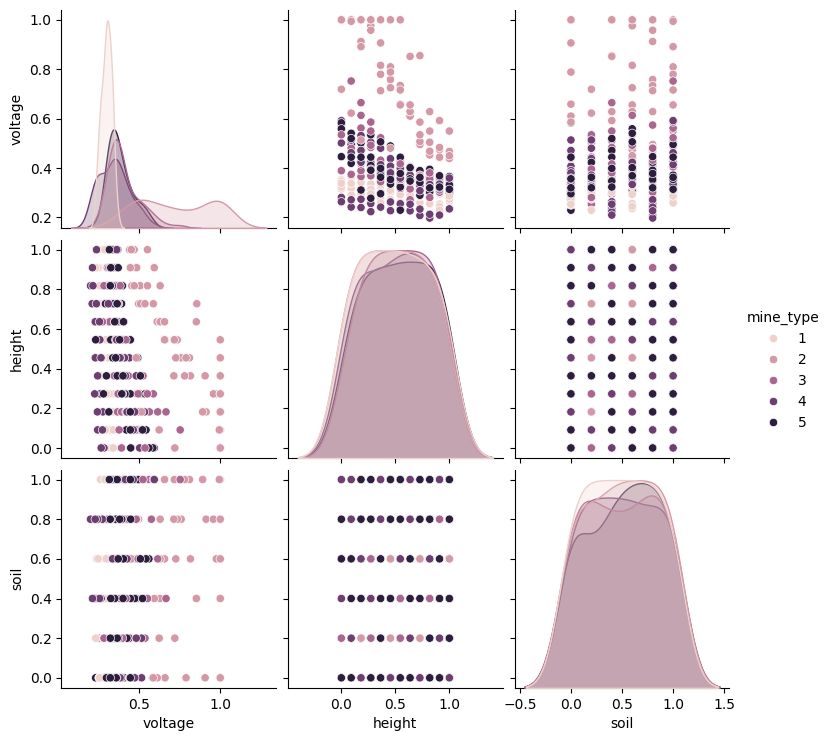

In [4]:

df = pd.read_csv('./data/land_mines.csv')
df.head()

#eda
df.describe()
print(df['mine_type'].value_counts())
print(df.isna().sum())
print(df.describe())
sns.pairplot(df, hue="mine_type")
plt.show()


col_0       1   2   3  4  5
mine_type                  
1          24   0   7  3  2
2           1  25   4  4  1
3           9   2   8  7  7
4          11   1  10  7  4
5          10   2  11  5  4
0.40236686390532544


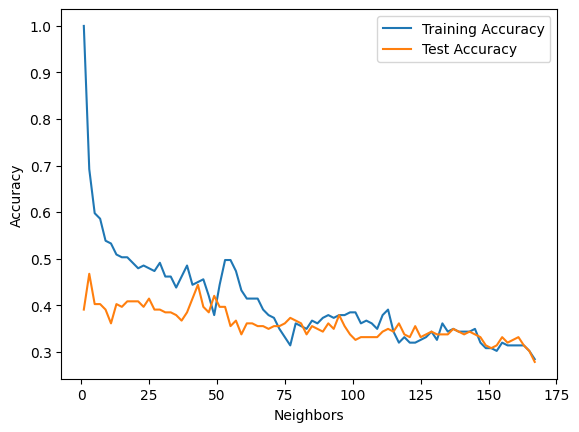

[3]
col_0       1   2   3  4  5
mine_type                  
1          26   0   4  2  4
2           0  30   2  2  1
3          12   3  10  1  7
4           9   4  10  8  2
5          10   1  14  2  5


0.46745562130177515

In [5]:
#50/50
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

y = df['mine_type']
ctrl_list = ['voltage','height','soil']
x = df.loc[:, ctrl_list]

scaler = MinMaxScaler()
u = pd.DataFrame(scaler.fit_transform(x), columns=ctrl_list)


from sklearn.model_selection import train_test_split

u_train, u_test, y_train, y_test = train_test_split(
    u, y,
    test_size = 0.5,
    random_state = 100,
    stratify = y
)
from sklearn.neighbors import KNeighborsClassifier

k = 5  #initial

model = KNeighborsClassifier(n_neighbors=k)
model = model.fit(u_train, y_train)

y_hat = model.predict(u_test)


print(pd.crosstab(y_test, y_hat))
print(model.score(u_test, y_test))


#k_grid = np.array([(2*k+3) for k in range(0,150)]) didn't work because it was
#out of range

max_k = len(u_train)
k_grid = np.arange(1, max_k, 2)

test_accuracies = []
train_accuracies = []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model = model.fit(u_train, y_train)

    test_acc = model.score(u_test, y_test)
    train_acc = model.score(u_train, y_train)

    test_accuracies.append(test_acc)
    train_accuracies.append(train_acc)

sns.lineplot(x=k_grid, y=train_accuracies, label='Training Accuracy')
sns.lineplot(x=k_grid, y=test_accuracies, label='Test Accuracy')
plt.xlabel("Neighbors")
plt.ylabel("Accuracy")
plt.show()

optimal = test_accuracies == np.max(test_accuracies)
optimal_indices = np.where(optimal)
k_optimal = k_grid[optimal_indices]

print(k_optimal)


model = KNeighborsClassifier(n_neighbors=int(k_optimal[0]))
model = model.fit(u_train, y_train)

y_hat = model.predict(u_test)

print(pd.crosstab(y_test, y_hat))
(model.score(u_test, y_test))





**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?

As K increased, the general slope of these graphs began to increase. This means that actual price started to line up a little more with predicted price since the entirity of the y axis could be fit into the first few values of the x-axis. As K increased there were fewer points going further into the graph in the x direction.

5. Determine the optimal $k$ for these data.

The optimal k was k = 100

6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

As K increased, the model became more prone to underfitting, while smaller values of K caused overfitting. With small K, the predicted points follow the training points, making the predictions sensitive to small variations. This resulted in a scatterplot where points are tightly clustered along the training data but deviate at times. Larger K causes underfitting: the predicted prices are less responsive to local deviations and are pulled toward the overall mean. The data is spread in a more random manner as K increases because more detailed patterns would be missed.

              price         year       mileage
count   2499.000000  2499.000000  2.499000e+03
mean   18767.671469  2016.714286  5.229869e+04
std    12116.094936     3.442656  5.970552e+04
min        0.000000  1973.000000  0.000000e+00
25%    10200.000000  2016.000000  2.146650e+04
50%    16900.000000  2018.000000  3.536500e+04
75%    25555.500000  2019.000000  6.347250e+04
max    84900.000000  2020.000000  1.017936e+06
(2499, 3)


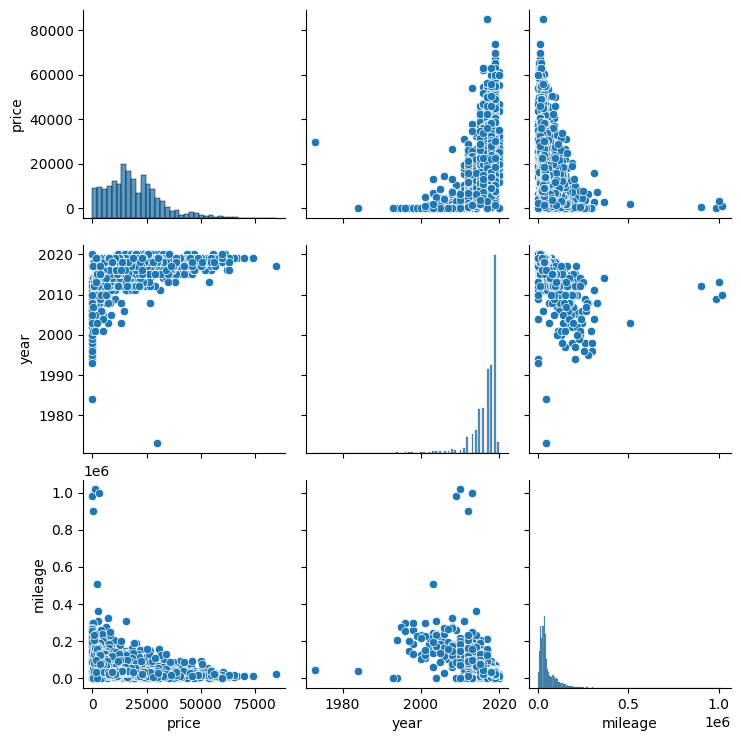

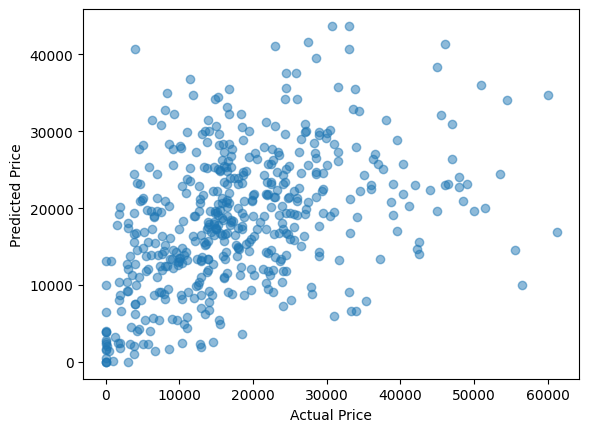

MSE for k=3: 126446573.21822222


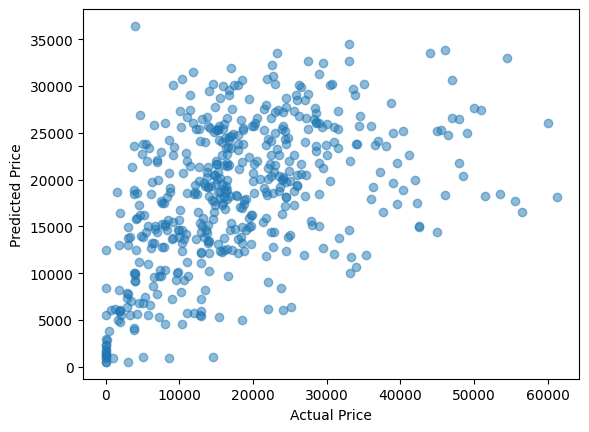

MSE for k=10: 110802185.58681999


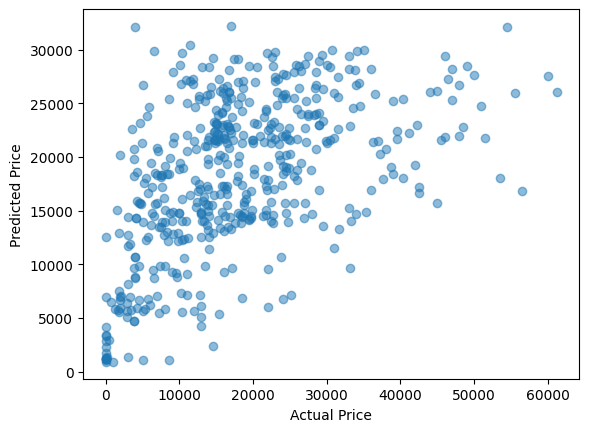

MSE for k=25: 103170457.848608


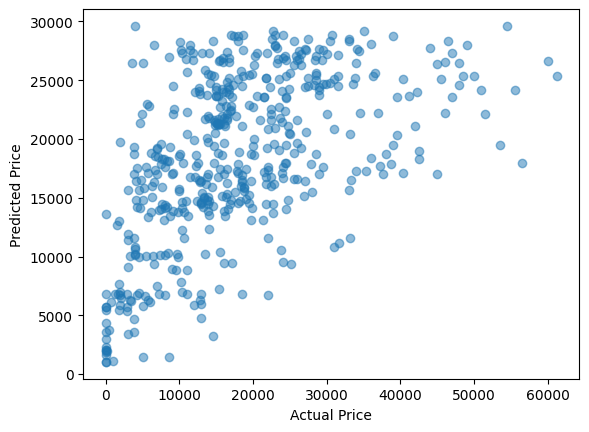

MSE for k=50: 99694130.3796272


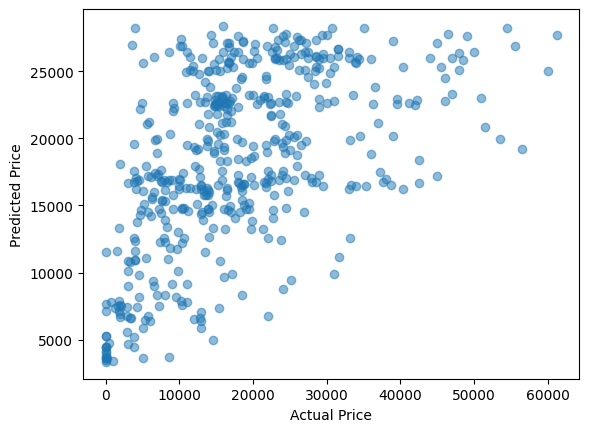

MSE for k=100: 98271058.96092059


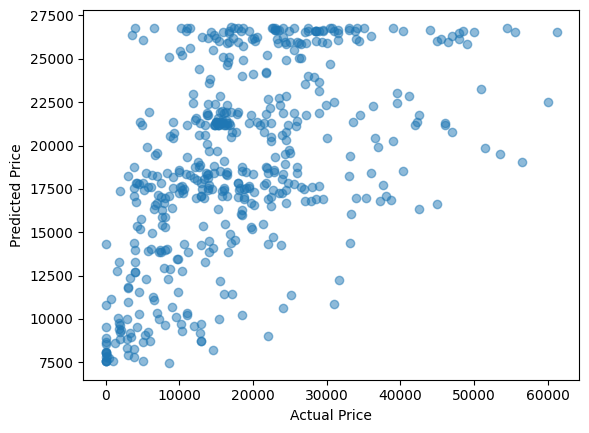

MSE for k=300: 100477298.914212
Optimal k: 100


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/data/USA_cars_datasets.csv')
df = df[['price', 'year', 'mileage']]
df.head()
print(df.describe())
df.isna().sum()
print(df.shape)
sns.pairplot(df)
plt.show()



#maxmin
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = df[['year','mileage']]
y = df['price']

x_scaled = scaler.fit_transform(X)


#split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x_scaled, y,
    test_size=0.2,
    random_state=100
)


#4
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

k_values= [3,10,25,50,100,300]
mse_values = []

for k in k_values:
  model = KNeighborsRegressor(n_neighbors=k)
  model = model.fit(X_train, y_train)
  y_hat = model.predict(X_test)
  mse = mean_squared_error(y_test, y_hat)
  mse_values.append(mse)
  plt.scatter(y_test, y_hat, alpha=0.5)
  plt.xlabel("Actual Price")
  plt.ylabel("Predicted Price")
  plt.show()
  print(f"MSE for k={k}: {mse}")


#5, optimal K = the one with the smallest MSE
optimal_k = k_values[np.argmin(mse_values)]
print("Optimal k:", optimal_k)



**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

The two look similar in the sense that they both peak in the same areas, however, the extent to which each peaks is extremely different. In other words, training ratings and predicted ratings were similar in terms of the x-axis but not the y-axis.

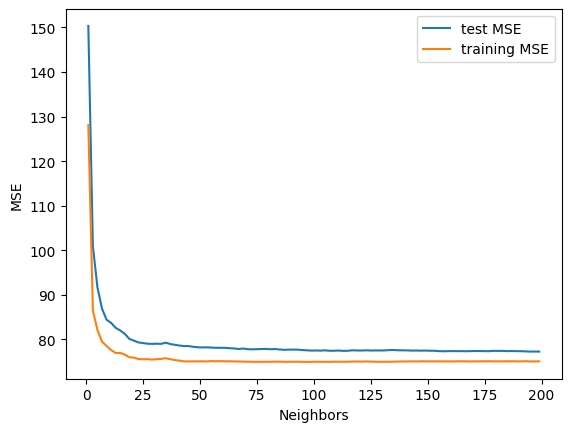

Optimal k: 195


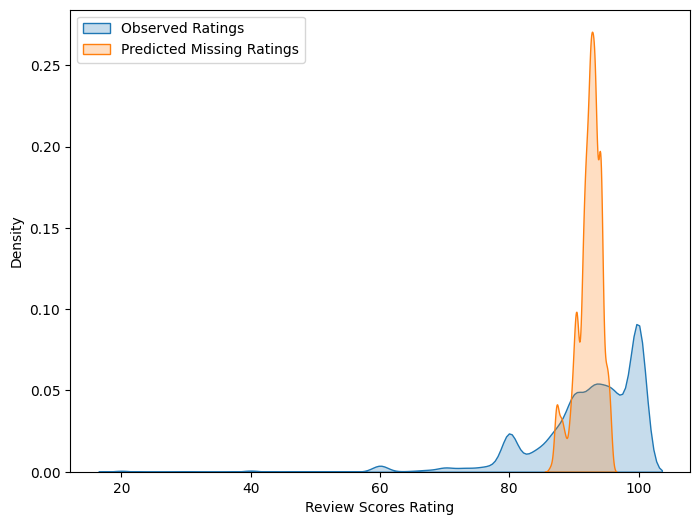

In [8]:
df = pd.read_csv('/content/data/airbnb_hw.csv')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df_missing = df.loc[df['Review Scores Rating'].isnull()]

# drop rows
df = df.dropna(axis=0, how='any')

x = df[['Price', 'Beds']]
y = df['Review Scores Rating']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
xscale = scaler.fit_transform(x)

#train/test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    xscale, y, test_size=0.2, random_state=100
)

#find best k
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

k_grid = [ (2*k+1) for k in range(100)]
mses = []
mses_train = []

for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train, y_train)
    y_hat = model.predict(x_test)
    mses_train.append(mean_squared_error(y_train, model.predict(x_train)))
    mses.append(mean_squared_error(y_test, y_hat))

# plot MSE vs k
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=k_grid, y=mses, label='test MSE')
sns.lineplot(x=k_grid, y=mses_train, label='training MSE')
plt.xlabel("Neighbors")
plt.ylabel("MSE")
plt.show()

# best k to predict missing ratings
best_k = k_grid[np.argmin(mses)]
print("Optimal k:", best_k)

model = KNeighborsRegressor(n_neighbors=best_k)
model.fit(xscale, y)

df_missing = df_missing.dropna(subset=['Price','Beds'])
x_missing_scaled = scaler.transform(df_missing[['Price','Beds']])
predicted_ratings = model.predict(x_missing_scaled)
df_missing['Predicted Rating'] = predicted_ratings

# kde plot
plt.figure(figsize=(8,6))
sns.kdeplot(y, label="Observed Ratings", fill=True)
sns.kdeplot(predicted_ratings, label="Predicted Missing Ratings", fill=True)
plt.xlabel("Review Scores Rating")
plt.ylabel("Density")
plt.legend()
plt.show()



**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)